In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, normaltest, zscore, spearmanr, pearsonr
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Loaded Successfully")

In [3]:
df = pd.read_csv("ecommerce_dataset.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (5000, 15)


,transaction_id,customer_id,timestamp,product_category,product_price,quantity,discount_pct,customer_age,is_returning_customer,device_type,region,payment_method,total_price,final_price,date
0,1,4174,2023-01-01 00:00:00,Electronics,32.034680,5,5.0,NaN,False,Mobile,South,Credit Card,160.173401,152.164731,2023-01-01
1,2,4507,2023-01-01 08:00:00,Electronics,147.516914,1,10.0,21.0,False,Mobile,West,PayPal,147.516914,132.765223,2023-01-01
2,3,1860,2023-01-01 16:00:00,Clothing,89.375768,2,0.0,40.0,True,Mobile,West,Bank Transfer,178.751536,178.751536,2023-01-01
3,4,2294,2023-01-02 00:00:00,Clothing,244.525565,3,5.0,45.0,False,Mobile,West,Credit Card,733.576694,696.897859,2023-01-02
4,5,2130,2023-01-02 08:00:00,Electronics,272.411662,1,15.0,39.0,False,Mobile,East,PayPal,272.411662,231.549913,2023-01-02


In [4]:
print(df.info())

memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nTotal Memory Usage: {memory_usage:.2f} MB")

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         5000 non-null   int64  
 1   customer_id            5000 non-null   int64  
 2   timestamp              5000 non-null   str    
 3   product_category       5000 non-null   str    
 4   product_price          5000 non-null   float64
 5   quantity               5000 non-null   int64  
 6   discount_pct           4950 non-null   float64
 7   customer_age           4950 non-null   float64
 8   is_returning_customer  5000 non-null   bool   
 9   device_type            5000 non-null   str    
 10  region                 5000 non-null   str    
 11  payment_method         5000 non-null   str    
 12  total_price            5000 non-null   float64
 13  final_price            5000 non-null   float64
 14  date                   5000 non-null   str    
dtypes: bool(1), flo

In [5]:
missing_values = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum()/len(df))*100
})

missing_values = missing_values.sort_values(
    by='Missing_Percentage',
    ascending=False
)

overall_missing_percentage = (
    df.isnull().sum().sum() /
    (df.shape[0]*df.shape[1])
)*100

print("Overall Missing Percentage:",
      round(overall_missing_percentage,2),"%")

display(missing_values)

missing_values.to_csv(
    "data_quality_report.csv",
    index=True
)

Overall Missing Percentage: 0.13 %


,Missing_Count,Missing_Percentage
discount_pct,50,1.0
customer_age,50,1.0
customer_id,0,0.0
timestamp,0,0.0
product_category,0,0.0
product_price,0,0.0
transaction_id,0,0.0
quantity,0,0.0
is_returning_customer,0,0.0
device_type,0,0.0


In [6]:
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

duplicate_transaction_groups = 0

if 'transaction_id' in df.columns:
    duplicate_transaction_groups = (
        df.duplicated(subset=['transaction_id'])
        .sum()
    )

print("Duplicate Transaction Groups:",
      duplicate_transaction_groups)

Duplicate Rows: 0
Duplicate Transaction Groups: 0


In [7]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.astype(str),
    "Missing": df.isnull().sum()
})

display(dtype_report)

,Column,DataType,Missing
transaction_id,transaction_id,int64,0
customer_id,customer_id,int64,0
timestamp,timestamp,str,0
product_category,product_category,str,0
product_price,product_price,float64,0
quantity,quantity,int64,0
discount_pct,discount_pct,float64,50
customer_age,customer_age,float64,50
is_returning_customer,is_returning_customer,bool,0
device_type,device_type,str,0


In [8]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print(numeric_cols)

['transaction_id', 'customer_id', 'product_price', 'quantity', 'discount_pct', 'customer_age', 'total_price', 'final_price']


In [9]:
stats_profile = df[numeric_cols].describe().T

stats_profile['median'] = df[numeric_cols].median()

stats_profile = stats_profile[
    ['count','mean','std','min',
     '25%','median','50%',
     '75%','max']
]

display(stats_profile)

stats_profile.to_csv(
    "statistical_profile.csv"
)

,count,mean,std,min,25%,median,50%,75%,max
transaction_id,5000.0,2500.500000,1443.520003,1.000000,1250.750000,2500.500000,2500.500000,3750.250000,5000.000000
customer_id,5000.0,3008.979400,1147.760648,1000.000000,2008.750000,3000.500000,3000.500000,4006.000000,4999.000000
product_price,5000.0,118.521610,98.108931,20.005283,48.967381,87.880759,87.880759,157.079259,822.617824
quantity,5000.0,3.045000,1.438120,1.000000,2.000000,3.000000,3.000000,4.000000,10.000000
discount_pct,4950.0,4.876768,6.068825,0.000000,0.000000,0.000000,0.000000,10.000000,20.000000
customer_age,4950.0,37.907677,11.396337,18.000000,29.250000,38.000000,38.000000,46.000000,78.000000
total_price,5000.0,359.228978,357.609693,20.566814,122.138075,234.806908,234.806908,464.059637,3186.525446
final_price,5000.0,342.267620,343.454387,17.481792,115.825805,225.980904,225.980904,442.576383,3027.199174


In [10]:
distribution_metrics = pd.DataFrame({
    "Skewness":
        df[numeric_cols].apply(skew),

    "Kurtosis":
        df[numeric_cols].apply(kurtosis)
})

display(distribution_metrics)

,Skewness,Kurtosis
transaction_id,0.000000,-1.200000
customer_id,-0.008062,-1.198486
product_price,1.940399,5.280326
quantity,0.755011,0.587671
discount_pct,NaN,NaN
customer_age,NaN,NaN
total_price,2.272652,6.772935
final_price,2.318745,7.149950


In [11]:
normality_results = []

test_columns = numeric_cols[:3]

for col in test_columns:

    stat,p = normaltest(
        df[col].dropna()
    )

    interpretation = (
        "Normally Distributed"
        if p > 0.05
        else "Not Normally Distributed"
    )

    normality_results.append([
        col, stat, p, interpretation
    ])

normality_df = pd.DataFrame(
    normality_results,
    columns=[
        "Column",
        "Statistic",
        "P_Value",
        "Interpretation"
    ]
)

display(normality_df)

,Column,Statistic,P_Value,Interpretation
0,transaction_id,4260.182407,0.0,Not Normally Distributed
1,customer_id,4201.751343,0.0,Not Normally Distributed
2,product_price,2008.578533,0.0,Not Normally Distributed


In [12]:
iqr_results = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    iqr_results.append([
        col,
        count
    ])

iqr_df = pd.DataFrame(
    iqr_results,
    columns=[
        'Column',
        'IQR_Outliers'
    ]
)

display(iqr_df)

,Column,IQR_Outliers
0,transaction_id,0
1,customer_id,0
2,product_price,230
3,quantity,35
4,discount_pct,0
5,customer_age,10
6,total_price,326
7,final_price,321


In [13]:
zscore_results = []

for col in numeric_cols:

    z = np.abs(
        stats.zscore(
            df[col].fillna(
                df[col].median()
            )
        )
    )

    count = (z > 3).sum()

    zscore_results.append([
        col,
        count
    ])

zscore_df = pd.DataFrame(
    zscore_results,
    columns=[
        "Column",
        "Zscore_Outliers"
    ]
)

display(zscore_df)

,Column,Zscore_Outliers
0,transaction_id,0
1,customer_id,0
2,product_price,92
3,quantity,35
4,discount_pct,0
5,customer_age,10
6,total_price,116
7,final_price,115


In [14]:
outlier_comparison = pd.merge(
    iqr_df,
    zscore_df,
    on='Column'
)

display(outlier_comparison)

,Column,IQR_Outliers,Zscore_Outliers
0,transaction_id,0,0
1,customer_id,0,0
2,product_price,230,92
3,quantity,35,35
4,discount_pct,0,0
5,customer_age,10,10
6,total_price,326,116
7,final_price,321,115


In [15]:
if 'final_price' in df.columns:

    Q1 = df['final_price'].quantile(0.25)
    Q3 = df['final_price'].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    final_price_outliers = df[
        (df['final_price']<lower) |
        (df['final_price']>upper)
    ]

    top10_outliers = (
        final_price_outliers
        .sort_values(
            by='final_price',
            ascending=False
        )
        .head(10)
    )

    display(top10_outliers)

    top10_outliers.to_csv(
        "outlier_detection.csv",
        index=False
    )

,transaction_id,customer_id,timestamp,product_category,product_price,quantity,discount_pct,customer_age,is_returning_customer,device_type,region,payment_method,total_price,final_price,date
2741,2742,3212,2025-07-02 16:00:00,Beauty,637.305089,5,5.0,30.0,True,Mobile,West,PayPal,3186.525446,3027.199174,2025-07-02
4842,4843,1557,2027-06-03 00:00:00,Clothing,684.422388,4,0.0,62.0,False,Mobile,East,Credit Card,2737.689553,2737.689553,2027-06-03
1555,1556,4055,2024-06-02 08:00:00,Clothing,446.809614,6,0.0,36.0,False,Tablet,West,PayPal,2680.857686,2680.857686,2024-06-02
695,696,2687,2023-08-20 16:00:00,Electronics,416.486956,6,0.0,39.0,False,Mobile,East,Gift Card,2498.921739,2498.921739,2023-08-20
3387,3388,2597,2026-02-03 00:00:00,Beauty,822.617824,3,0.0,37.0,False,Mobile,South,PayPal,2467.853471,2467.853471,2026-02-03
1466,1467,2202,2024-05-03 16:00:00,Home,600.598226,4,0.0,53.0,False,Mobile,East,PayPal,2402.392905,2402.392905,2024-05-03
4933,4934,4805,2027-07-03 08:00:00,Electronics,505.001175,5,5.0,51.0,True,Tablet,Central,Credit Card,2525.005876,2398.755582,2027-07-03
138,139,3568,2023-02-16 00:00:00,Clothing,590.877831,4,0.0,35.0,False,Mobile,West,PayPal,2363.511325,2363.511325,2023-02-16
4831,4832,3293,2027-05-30 08:00:00,Clothing,225.006068,10,0.0,46.0,False,Mobile,South,Credit Card,2250.060679,2250.060679,2027-05-30
2517,2518,4174,2025-04-19 00:00:00,Clothing,403.944492,6,10.0,19.0,False,Desktop,East,Credit Card,2423.666952,2181.300257,2025-04-19


,transaction_id,customer_id,product_price,quantity,discount_pct,customer_age,total_price,final_price
transaction_id,1.000000,0.000670,0.038311,-0.008079,0.032032,0.002598,0.032963,0.032358
customer_id,0.000670,1.000000,0.001474,0.010831,-0.003159,-0.014880,-0.000385,0.000357
product_price,0.038311,0.001474,1.000000,-0.011834,-0.012340,0.010398,0.808062,0.803862
quantity,-0.008079,0.010831,-0.011834,1.000000,-0.020999,0.011807,0.454401,0.452616
discount_pct,0.032032,-0.003159,-0.012340,-0.020999,1.000000,-0.024275,-0.024299,-0.085566
customer_age,0.002598,-0.014880,0.010398,0.011807,-0.024275,1.000000,0.017040,0.017619
total_price,0.032963,-0.000385,0.808062,0.454401,-0.024299,0.017040,1.000000,0.996182
final_price,0.032358,0.000357,0.803862,0.452616,-0.085566,0.017619,0.996182,1.000000


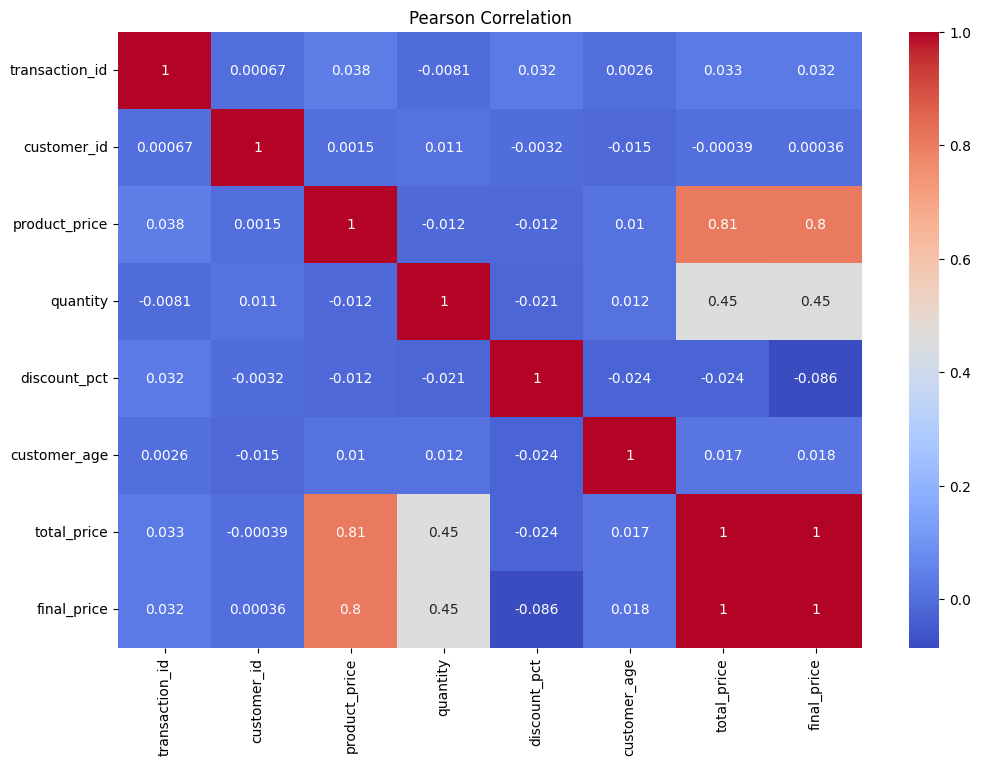

In [16]:
pearson_corr = (
    df[numeric_cols]
    .corr(method='pearson')
)

display(pearson_corr)

plt.figure(figsize=(12,8))
sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Pearson Correlation")
plt.show()

In [17]:
spearman_corr = (
    df[numeric_cols]
    .corr(method='spearman')
)

display(spearman_corr)

,transaction_id,customer_id,product_price,quantity,discount_pct,customer_age,total_price,final_price
transaction_id,1.000000,0.000863,0.022953,-0.001136,0.027061,0.005867,0.021355,0.019268
customer_id,0.000863,1.000000,0.002677,0.001470,-0.003112,-0.013403,0.010851,0.011178
product_price,0.022953,0.002677,1.000000,-0.003309,-0.015827,0.006918,0.835906,0.833652
quantity,-0.001136,0.001470,-0.003309,1.000000,-0.009684,0.008953,0.515996,0.515028
discount_pct,0.027061,-0.003112,-0.015827,-0.009684,1.000000,-0.028006,-0.016301,-0.081143
customer_age,0.005867,-0.013403,0.006918,0.008953,-0.028006,1.000000,0.007945,0.009432
total_price,0.021355,0.010851,0.835906,0.515996,-0.016301,0.007945,1.000000,0.997394
final_price,0.019268,0.011178,0.833652,0.515028,-0.081143,0.009432,0.997394,1.000000


In [19]:
corr_matrix = (
    pearson_corr
    .abs()
    .unstack()
    .sort_values(
        ascending=False
    )
)

corr_matrix = corr_matrix[
    corr_matrix < 1
]

strong_corr = corr_matrix[
    corr_matrix > 0.3
]

strong_corr = strong_corr.reset_index()

strong_corr.columns = [
    'Variable1',
    'Variable2',
    'Correlation'
]

strong_corr = strong_corr.drop_duplicates()

display(strong_corr)

strong_corr.to_csv(
    "strong_correlations.csv",
    index=False
)

,Variable1,Variable2,Correlation
0,final_price,total_price,0.996182
1,total_price,final_price,0.996182
2,product_price,total_price,0.808062
3,total_price,product_price,0.808062
4,final_price,product_price,0.803862
5,product_price,final_price,0.803862
6,quantity,total_price,0.454401
7,total_price,quantity,0.454401
8,final_price,quantity,0.452616
9,quantity,final_price,0.452616


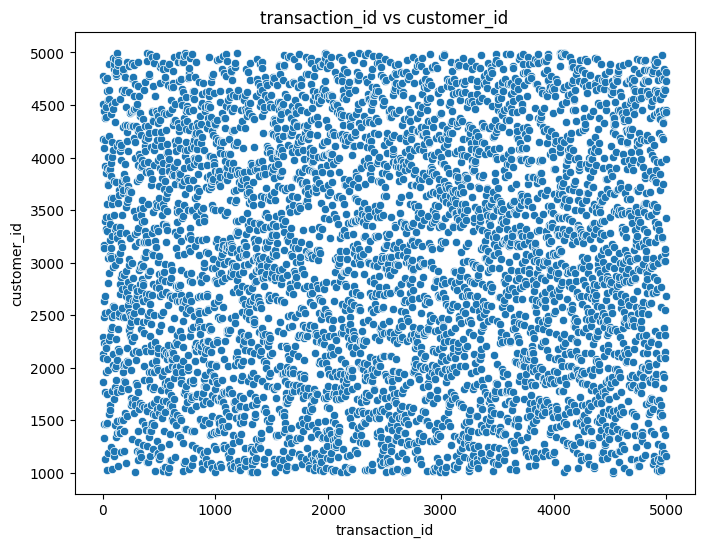

In [20]:
if len(numeric_cols) >= 2:

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=df,
        x=numeric_cols[0],
        y=numeric_cols[1]
    )

    plt.title(
        f"{numeric_cols[0]} vs {numeric_cols[1]}"
    )

    plt.show()

In [21]:
if (
    'product_category' in df.columns and
    'final_price' in df.columns
):

    category_analysis = (
        df.groupby('product_category')
        .agg(
            Revenue=('final_price','sum'),
            Avg_Order_Value=('final_price','mean'),
            Transactions=('final_price','count')
        )
        .sort_values(
            by='Revenue',
            ascending=False
        )
    )

    display(category_analysis)

,Revenue,Avg_Order_Value,Transactions
product_category,,,
Clothing,521452.660347,340.596120,1531
Electronics,454379.253120,355.539322,1278
Home,314240.237796,322.628581,974
Beauty,245561.876719,339.642983,723
Sports,175704.073443,355.676262,494


In [22]:
if (
    'region' in df.columns and
    'device_type' in df.columns and
    'final_price' in df.columns
):

    revenue_region_device = (
        df.groupby(
            ['region','device_type']
        )['final_price']
        .sum()
        .reset_index()
    )

    display(revenue_region_device)

,region,device_type,final_price
0,Central,Desktop,55548.082414
1,Central,Mobile,101652.589294
2,Central,Tablet,21728.362898
3,East,Desktop,125556.757353
4,East,Mobile,281011.604182
5,East,Tablet,45351.413645
6,North,Desktop,103055.668145
7,North,Mobile,189747.454291
8,North,Tablet,31433.244988
9,South,Desktop,124368.734566


In [23]:
customer_col = None

possible_cols = [
    'customer_type',
    'is_returning_customer',
    'returning_customer'
]

for col in possible_cols:
    if col in df.columns:
        customer_col = col
        break

if customer_col:

    customer_revenue = (
        df.groupby(customer_col)
        ['final_price']
        .sum()
    )

    customer_share = (
        customer_revenue /
        customer_revenue.sum()
    )*100

    display(customer_share)

is_returning_customer
False    68.944523
True     31.055477
Name: final_price, dtype: float64

In [24]:
if 'final_price' in df.columns:

    df['Customer_Segment'] = pd.qcut(
        df['final_price'],
        4,
        labels=[
            'Low Value',
            'Medium Value',
            'High Value',
            'Premium'
        ]
    )

    segment_table = (
        df.groupby(
            'Customer_Segment'
        )
        .agg(
            Customers=('final_price','count'),
            Revenue=('final_price','sum'),
            Avg_Order_Value=('final_price','mean')
        )
    )

    display(segment_table)

    segment_table.to_csv(
        "segment_analysis.csv"
    )

,Customers,Revenue,Avg_Order_Value
Customer_Segment,,,
Low Value,1250,9.264984e+04,74.119868
Medium Value,1250,2.082206e+05,166.576494
High Value,1250,3.985429e+05,318.834312
Premium,1250,1.011925e+06,809.539807


In [25]:
date_col = None

possible_date_cols = [
    'transaction_date',
    'date',
    'order_date',
    'purchase_date'
]

for col in possible_date_cols:
    if col in df.columns:
        date_col = col
        break

if date_col:

    df[date_col] = pd.to_datetime(
        df[date_col]
    )

    print("Date Column:", date_col)

Date Column: date


In [26]:
if date_col:

    daily_revenue = (
        df.groupby(
            df[date_col].dt.date
        )['final_price']
        .sum()
        .reset_index()
    )

    daily_revenue.columns = [
        'Date',
        'Revenue'
    ]

    daily_revenue['MA7'] = (
        daily_revenue['Revenue']
        .rolling(7)
        .mean()
    )

    daily_revenue['MA14'] = (
        daily_revenue['Revenue']
        .rolling(14)
        .mean()
    )

    display(daily_revenue.head())

,Date,Revenue,MA7,MA14
0,2023-01-01,463.681489,NaN,NaN
1,2023-01-02,1005.468593,NaN,NaN
2,2023-01-03,807.122721,NaN,NaN
3,2023-01-04,710.489748,NaN,NaN
4,2023-01-05,536.932800,NaN,NaN


In [27]:
if date_col:

    df['Day_of_Week'] = (
        df[date_col]
        .dt.day_name()
    )

    day_analysis = (
        df.groupby(
            'Day_of_Week'
        )['final_price']
        .sum()
        .sort_values(
            ascending=False
        )
    )

    display(day_analysis)

Day_of_Week
Tuesday      255285.251096
Wednesday    252961.670802
Saturday     251324.900042
Thursday     244751.460686
Friday       238684.397954
Sunday       235059.580559
Monday       233270.840286
Name: final_price, dtype: float64

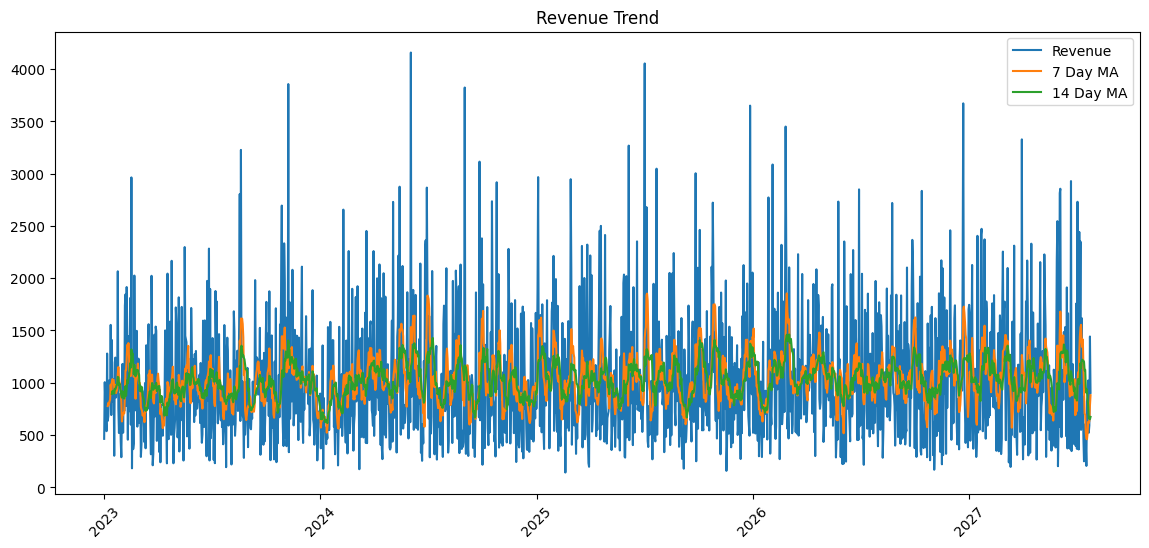

In [28]:
if date_col:

    plt.figure(figsize=(14,6))

    plt.plot(
        daily_revenue['Date'],
        daily_revenue['Revenue'],
        label='Revenue'
    )

    plt.plot(
        daily_revenue['Date'],
        daily_revenue['MA7'],
        label='7 Day MA'
    )

    plt.plot(
        daily_revenue['Date'],
        daily_revenue['MA14'],
        label='14 Day MA'
    )

    plt.legend()

    plt.title(
        "Revenue Trend"
    )

    plt.xticks(rotation=45)

    plt.show()

In [29]:
if date_col:

    df['Transaction_Month'] = (
        df[date_col].dt.month
    )

    df['Transaction_Weekday'] = (
        df[date_col].dt.dayofweek
    )

if (
    'final_price' in df.columns and
    'quantity' in df.columns
):

    df['Revenue_per_Unit'] = (
        df['final_price'] /
        df['quantity']
    )

display(df.head())

,transaction_id,customer_id,timestamp,product_category,product_price,quantity,discount_pct,customer_age,is_returning_customer,device_type,region,payment_method,total_price,final_price,date,Customer_Segment,Day_of_Week,Transaction_Month,Transaction_Weekday,Revenue_per_Unit
0,1,4174,2023-01-01 00:00:00,Electronics,32.034680,5,5.0,NaN,False,Mobile,South,Credit Card,160.173401,152.164731,2023-01-01,Medium Value,Sunday,1,6,30.432946
1,2,4507,2023-01-01 08:00:00,Electronics,147.516914,1,10.0,21.0,False,Mobile,West,PayPal,147.516914,132.765223,2023-01-01,Medium Value,Sunday,1,6,132.765223
2,3,1860,2023-01-01 16:00:00,Clothing,89.375768,2,0.0,40.0,True,Mobile,West,Bank Transfer,178.751536,178.751536,2023-01-01,Medium Value,Sunday,1,6,89.375768
3,4,2294,2023-01-02 00:00:00,Clothing,244.525565,3,5.0,45.0,False,Mobile,West,Credit Card,733.576694,696.897859,2023-01-02,Premium,Monday,1,0,232.299286
4,5,2130,2023-01-02 08:00:00,Electronics,272.411662,1,15.0,39.0,False,Mobile,East,PayPal,272.411662,231.549913,2023-01-02,High Value,Monday,1,0,231.549913


In [30]:
#MULTIINDEX WEEKLY SALES

if (
    date_col and
    'product_category' in df.columns
):

    weekly_sales = (
        df.groupby([
            pd.Grouper(
                key=date_col,
                freq='W'
            ),
            'product_category'
        ])
        ['final_price']
        .sum()
    )

    display(weekly_sales)

date        product_category
2023-01-01  Clothing             178.751536
            Electronics          284.929953
2023-01-08  Beauty               715.798386
            Clothing            1536.889782
            Electronics          700.790923
                                   ...     
2027-07-25  Beauty              1247.161200
            Clothing            1829.478623
            Electronics          365.152793
            Home                2376.566707
            Sports               347.533718
Name: final_price, Length: 1155, dtype: float64

In [31]:
#HIGH VALUE CUSTOMER SCORE


score_columns = []

for col in numeric_cols:
    if col != 'final_price':
        score_columns.append(col)

if len(score_columns) > 0:

    scaler = StandardScaler()

    scaled = scaler.fit_transform(
        df[score_columns]
        .fillna(0)
    )

    df['High_Value_Score'] = (
        scaled.mean(axis=1)
    )

    display(
        df[
            ['High_Value_Score']
        ].head()
    )

,High_Value_Score
0,-0.558238
1,-0.381967
2,-0.692894
3,0.085874
4,-0.112657


In [33]:
#LOGISTIC REGRESSION

target_col = None

for col in [
    'is_returning_customer',
    'returning_customer'
]:
    if col in df.columns:
        target_col = col
        break

if target_col:

    model_data = df.copy()

    model_data = pd.get_dummies(
        model_data,
        drop_first=True
    )

    X = model_data.drop(
        columns=[target_col],
        errors='ignore'
    )

    y = model_data[target_col]

    X = X.fillna(0)

    X_train,X_test,y_train,y_test = (
        train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )
    )

    model = LogisticRegression(
        max_iter=5000
    )

    # ensure X_train/X_test contain only numeric/bool dtypes (drop datetimes/objects)
    valid_cols = X_train.select_dtypes(include=[np.number, 'bool']).columns
    X_train = X_train[valid_cols].astype(float)
    X_test = X_test[valid_cols].astype(float)

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            preds
        )
    )

    print(
        classification_report(
            y_test,
            preds
        )
    )

Accuracy: 0.662
              precision    recall  f1-score   support

       False       0.68      0.95      0.79       675
        True       0.38      0.06      0.11       325

    accuracy                           0.66      1000
   macro avg       0.53      0.51      0.45      1000
weighted avg       0.58      0.66      0.57      1000

